# **Multi-Armed Bandit Problem**
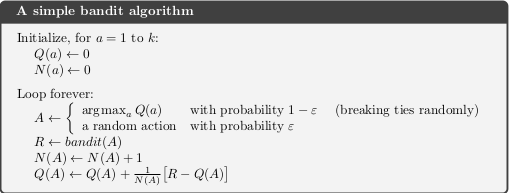

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

**Variable Descriptions**

- `k` → Number of arms  
- `true_action_values` → True action values (true mean rewards)  
- `reward_variance` → Reward variance for each arm  
- `Q_est` → Estimated action-value function  
- `N` → Number of times each arm is selected  
- `epsilon` → Exploration probability  
- `A` → Selected action  
- `R` → Observed reward  
- `cumulative_reward` → Cumulative reward


mean_value = [13  3  4 10  9  2 11  7  8  5]
Q_est (Estimated action-value function) = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
N (Number of times each arm is selected) = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
epsilon = 0.1
----------------------------------------
----------------------------------------


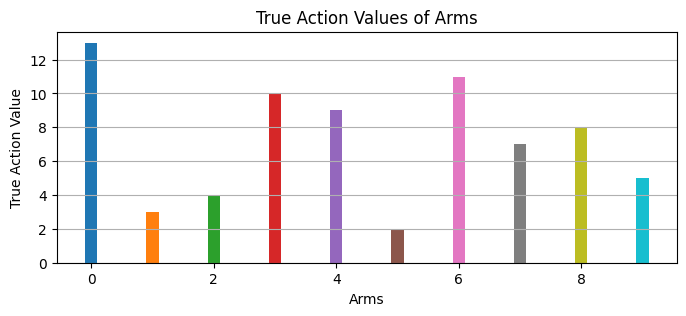

In [ ]:
# np.random.seed(4)

k = 10 # Number of arms (actions)
n_steps = 2000

true_action_values = np.random.choice(10, size=k, replace=False) # Optimal action values

Q_est = np.zeros(k) # Estimated action-value function
N = np.zeros(k) # Number of times each arm is selected
epsilon = 0.1
cumulative_reward = np.zeros(n_steps)
optimal_actions = np.zeros(n_steps)
selected_actions = np.zeros(n_steps)
OAP = np.zeros(n_steps) # Optimal Action Percent


print('mean_value =', true_action_values)
print('Q_est (Estimated action-value function) =', Q_est)
print('N (Number of times each arm is selected) =', N)
print('epsilon =', epsilon)

print('----------------------------------------')
print('----------------------------------------')


plt.figure(figsize=(8,3))

for i in range(true_action_values.size):
  plt.bar(i, true_action_values[i], width=0.2)

plt.ylabel('True Action Value')
plt.xlabel('Arms')
plt.title('True Action Values of Arms')
plt.grid(axis='y')
plt.show()

# **Epsilon-Greedy Algorithm for non-stationary (dynamic) systems**

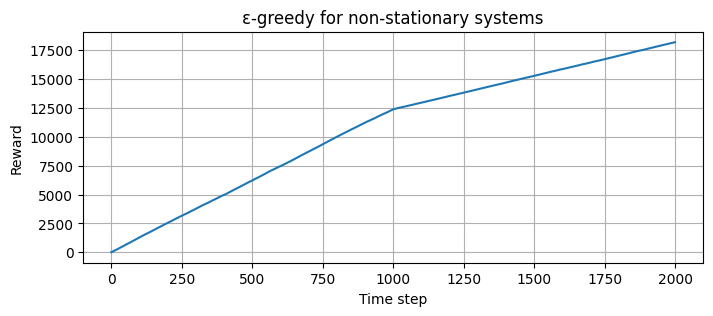

----------------------------------------
cumulative_reward =  18181.676980628636
----------------------------------------
q-star = [13  3  4 10  9  2 11  7  8  5]
q-star_new = [6 4 8 7 0 3 2 5 3 3]
----------------------------------------
Q_est =  [9.48296901 3.44419716 6.25187453 8.09054552 3.97155142 2.12997515
 6.76483779 6.05985356 5.05875116 3.78407742]
true_action_values =  [6 4 8 7 0 3 2 5 3 3]
----------------------------------------


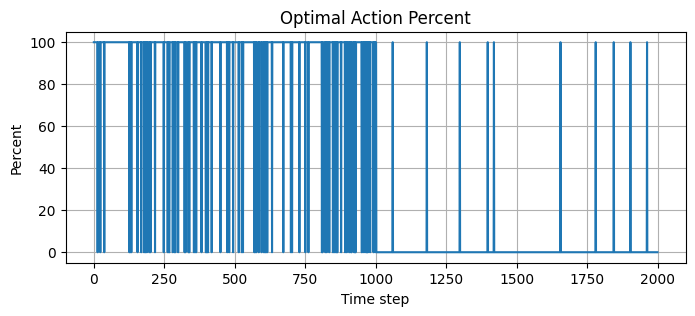

Optimal Action Percent =  45.85 %


In [ ]:
for i in range(n_steps):

  if(np.random.rand() > epsilon): # Exploitation
    # print('Exploitation')
    A = np.argmax(Q_est)
    N[A] = N[A] + 1
    R = true_action_values[A] + np.random.randn()
    Q_est[A] = Q_est[A] + (1/N[A]) * (R - Q_est[A]) # Sample average

  else: # Exploration
    # print('Exploration')
    A = np.random.randint(0, k)
    N[A] = N[A] + 1
    R = true_action_values[A] + np.random.randn()
    Q_est[A] = Q_est[A] + (1/N[A]) * (R - Q_est[A]) # Sample average


  optimal_actions[i] = np.argmax(true_action_values)
  selected_actions[i] = A
  OAP[i] = (optimal_actions[i] == selected_actions[i]) * 100


  if i==0:
    cumulative_reward[i] = R
  else:
    cumulative_reward[i] = cumulative_reward[i-1]+R

  if i==1000: # Dynamic system changes at i = 1000
    true_action_values_old = true_action_values
    true_action_values = np.random.choice(10, size=k, replace=False)




plt.figure(figsize=(8,3))
plt.plot(cumulative_reward)
plt.title('ε-greedy for non-stationary systems')
plt.ylabel('Reward')
plt.xlabel('Time step')
plt.grid()
plt.show()

print('----------------------------------------')
print('cumulative_reward = ', cumulative_reward[-1])
print('----------------------------------------')
print('q-star =', true_action_values_old)
print('q-star_new =', true_action_values)
print('----------------------------------------')

print('Q_est = ', Q_est)
print('true_action_values = ', true_action_values)
print('----------------------------------------')

plt.figure(figsize=(8,3))
plt.plot(OAP)
plt.xlabel('Time step')
plt.ylabel('Percent')
plt.title('Optimal Action Percent')
plt.grid()
plt.show()
print('Optimal Action Percent = ', ((np.sum(optimal_actions == selected_actions)*100))/n_steps, '%')